TITLE : IPL Data Analysis using Python

OBJECTIVE :  This project focuses on performing exploratory data analysis (EDA) on IPL match data to uncover patterns and insights related to team performance, toss decisions, venues, and player contributions.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("matches.csv")

# Data cleaning

In [3]:
df.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

In [4]:
# There are 51 values missing in city column which were filled with "unknown" to retain the data
df["city"] = df['city'].fillna('Unknown')

In [5]:
df['winner'] = df['winner'].fillna('No Result')

In [6]:
df['result_margin'] = df['result_margin'].fillna(0)

In [7]:
df.dropna(subset=['target_runs','target_overs'],inplace=True)

 Missing values in winner column were filled with"No Result" while a small number of rows with missing target values were removed to maintain data quality

# ANALYSIS :  WHICH TEAM WON MOST MATCHES?



In [8]:
team_map = {
    'Kings XI Punjab' : 'Punjab Kings',
    'Delhi Daredevils' : 'Delhi Capitals',
    'Royal Challengers Bengaluru' : 'Royal Challengers Bangalore',
    'Rising Pune Supergiant ' : 'Rising Pune Supergiants'
}

columns = ['team1','team2','winner','toss_winner']

for col in columns:
    df[col] = df[col].replace(team_map)

 Team names were standardized (eg,'Delhi Daredevils' to 'Delhi Capitals') to maintain consistency across seasons

In [9]:
df['winner'].value_counts()

winner
Mumbai Indians                 144
Chennai Super Kings            138
Kolkata Knight Riders          131
Royal Challengers Bangalore    123
Delhi Capitals                 115
Rajasthan Royals               112
Punjab Kings                   112
Sunrisers Hyderabad             88
Deccan Chargers                 29
Gujarat Titans                  28
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Kochi Tuskers Kerala             6
Rising Pune Supergiants          5
No Result                        2
Name: count, dtype: int64

# WHICH CITY HOST MOST MATCHES?

In [10]:
df['city'].value_counts().head(10)

city
Mumbai        173
Kolkata        93
Delhi          89
Chennai        85
Hyderabad      77
Bangalore      64
Chandigarh     61
Jaipur         57
Pune           51
Unknown        51
Name: count, dtype: int64

# WHICH TEAM PLAYED MOST MATCHES ?

In [11]:
pd.concat([df['team1'] , df['team2']]).value_counts()

Mumbai Indians                 261
Royal Challengers Bangalore    254
Delhi Capitals                 251
Kolkata Knight Riders          251
Punjab Kings                   246
Chennai Super Kings            237
Rajasthan Royals               220
Sunrisers Hyderabad            182
Deccan Chargers                 75
Pune Warriors                   45
Gujarat Titans                  45
Lucknow Super Giants            43
Gujarat Lions                   30
Rising Pune Supergiant          16
Kochi Tuskers Kerala            14
Rising Pune Supergiants         14
Name: count, dtype: int64

 INSIGHT:
 MUMBAI INDIANS HAS PLAYED THE MOST NUMBER OF MATCHES IN IPL HISTORY

<Axes: xlabel='winner'>

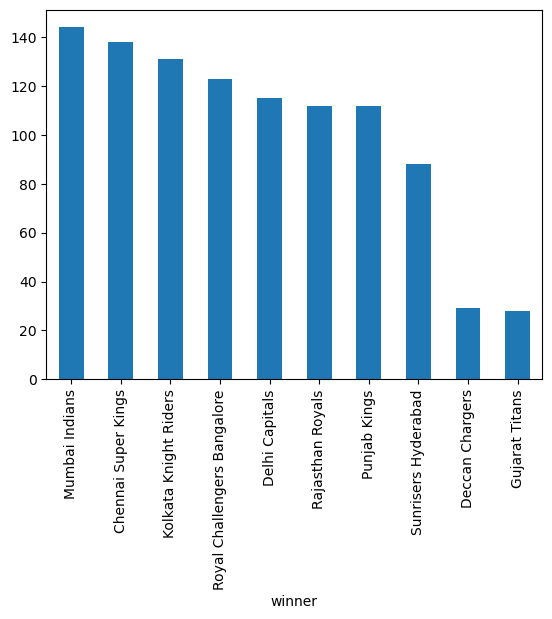

In [12]:
df["winner"].value_counts().head(10).plot(kind='bar')

MUMBAI INDIANS HAS WON  THE MOST NUMBER OF MATCHES IN IPL HISTORY.

# DOES WINNING THE TOSS HELPS IN MATCH WINNING?

In [13]:
toss_win_match = df[df['toss_winner'] == df['winner']].shape[0]
total_matches = df.shape[0]
print(toss_win_match,total_matches)

554 1092


In [14]:
percentage = (toss_win_match/total_matches) *100
print(percentage)

50.73260073260073


INSIGHT : "TEAMS THAT WIN THE TOSS ALSO WIN THE MATCH AROUND 50.7% OF THE TIME"

# WHICH TEAM DOMINATE EACH SEASON ? 

In [15]:
df.groupby(['season','winner']).size().reset_index(name='wins').sort_values(['season','wins'], ascending=[True,False]).drop_duplicates(subset = ['season'])

,season,winner,wins
6,2007/08,Rajasthan Royals,13
10,2009,Delhi Capitals,10
20,2009/10,Mumbai Indians,11
24,2011,Chennai Super Kings,11
37,2012,Kolkata Knight Riders,12
46,2013,Mumbai Indians,13
56,2014,Punjab Kings,12
60,2015,Chennai Super Kings,10
76,2016,Sunrisers Hyderabad,11
80,2017,Mumbai Indians,12


The data was grouped by season and team to count wins. Then, for each season, the team with the highest number of wins was identified as the dominant team.

INSIGHTS : Different teams dominated different IPL seasons. Mumbai Indians and Chennai Super Kings appear multiple times, showing consistent strong performance across years.

# WHICH PLAYER PERFORMED CONSISTENTLY?

In [16]:
df['player_of_match'].value_counts().head(10)

player_of_match
AB de Villiers    25
CH Gayle          22
RG Sharma         19
V Kohli           18
DA Warner         18
MS Dhoni          17
YK Pathan         16
RA Jadeja         16
SR Watson         16
AD Russell        15
Name: count, dtype: int64

<Axes: xlabel='player_of_match'>

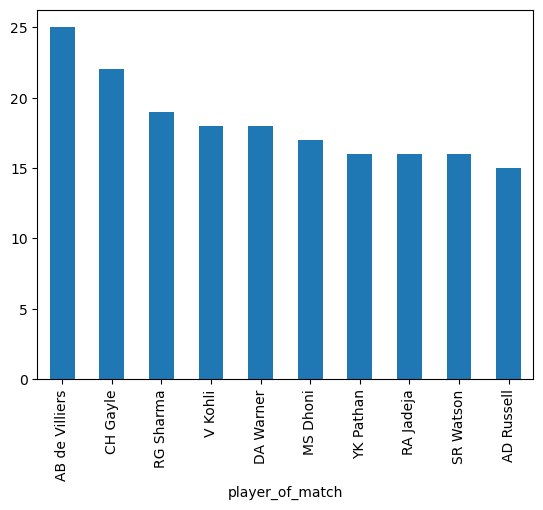

In [17]:
df['player_of_match'].value_counts().head(10).plot(kind='bar')

AB de villiers won most player of the match awards and performed consistently

 # WHICH TEAM WINS MORE WHEN BATTING FIRST VS CHASING ?

In [18]:
df['toss_decision'].value_counts()

toss_decision
field    702
bat      390
Name: count, dtype: int64

In [19]:
bat_wins = df[df['toss_decision'] == 'bat' ] ['winner'].value_counts()
field_wins = df[df['toss_decision'] == 'field' ] ['winner'].value_counts()

print(bat_wins,field_wins)

winner
Chennai Super Kings            63
Mumbai Indians                 54
Kolkata Knight Riders          50
Rajasthan Royals               43
Delhi Capitals                 42
Royal Challengers Bangalore    38
Sunrisers Hyderabad            30
Punjab Kings                   28
Deccan Chargers                14
Pune Warriors                   9
Gujarat Titans                  9
Lucknow Super Giants            6
Gujarat Lions                   2
Rising Pune Supergiants         2
Name: count, dtype: int64 winner
Mumbai Indians                 90
Royal Challengers Bangalore    85
Punjab Kings                   84
Kolkata Knight Riders          81
Chennai Super Kings            75
Delhi Capitals                 73
Rajasthan Royals               69
Sunrisers Hyderabad            58
Gujarat Titans                 19
Lucknow Super Giants           18
Deccan Chargers                15
Gujarat Lions                  11
Rising Pune Supergiant         10
Kochi Tuskers Kerala            6
Pune War

INSIGHT : TEAMS CHOOSE TO FIELD SEEMD TO WIN MORE MATCHES . 

<Axes: title={'center': 'Winning after Toss Decision'}, xlabel='toss_decision'>

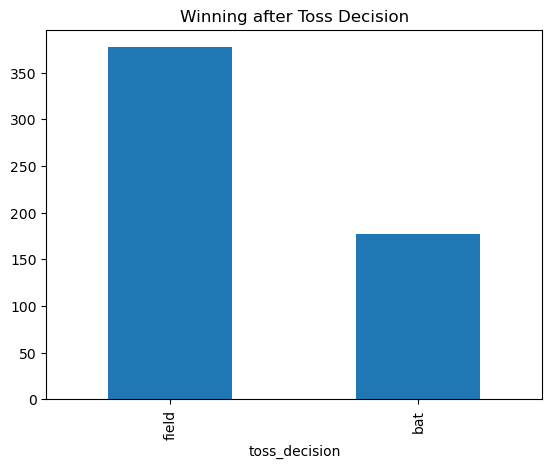

In [20]:
df[df['toss_winner'] == df['winner']]['toss_decision'].value_counts().plot(kind='bar', title='Winning after Toss Decision')

Teams choosing to field after winning the toss tend to win more matches, indicating a possible advantage in chasing

Final Insights:

- Mumbai Indians and Chennai Super Kings are the most dominant teams.
- Toss has a slight impact on match results.
- Teams often prefer fielding after winning the toss.
- Some venues host significantly more matches.
- Player performance strongly influences match outcomes.